1. Dataset Acquisition

In [ ]:
# Install the UCI repository package
!pip install ucimlrepo pandas matplotlib seaborn scikit-learn

import pandas as pd
from ucimlrepo import fetch_ucirepo

# Fetch dataset
ai4i = fetch_ucirepo(id=601)

# Data (as pandas dataframes)
X = ai4i.data.features
y = ai4i.data.targets

# Combine into one dataframe for EDA
df = pd.concat([X, y], axis=1)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (10000, 12)


,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


2. Data Preprocessing

In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Handle missing values (The AI4I dataset is usually clean, but this is a safety net)
df = df.dropna()

# 2. Encode Categorical Data ('Type' column: L, M, H)
le = LabelEncoder()
df['Type'] = le.fit_transform(df['Type'])

# 3. Separate features and our main target ('Machine failure')
# UPDATED: Removed the bracketed units from the column names to match the UCI format
features = ['Type', 'Air temperature', 'Process temperature',
            'Rotational speed', 'Torque', 'Tool wear']

X_preprocessed = df[features]
y_target = df['Machine failure']

# 4. Normalize sensor data to highlight critical wear-and-tear indicators
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_preprocessed), columns=features)

print("Preprocessing complete. Scaled features head:")
X_scaled.head()

Preprocessing complete. Scaled features head:


,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear
0,1.333889,-0.952389,-0.947360,0.068185,0.282200,-1.695984
1,-0.332223,-0.902393,-0.879959,-0.729472,0.633308,-1.648852
2,-0.332223,-0.952389,-1.014761,-0.227450,0.944290,-1.617430
3,-0.332223,-0.902393,-0.947360,-0.590021,-0.048845,-1.586009
4,-0.332223,-0.902393,-0.879959,-0.729472,0.001313,-1.554588


3. Exploratory Data Analysis (EDA)

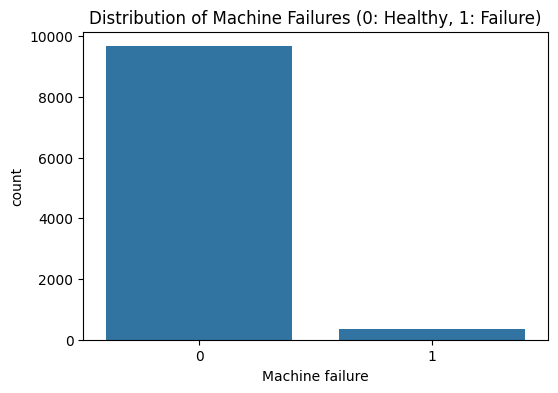

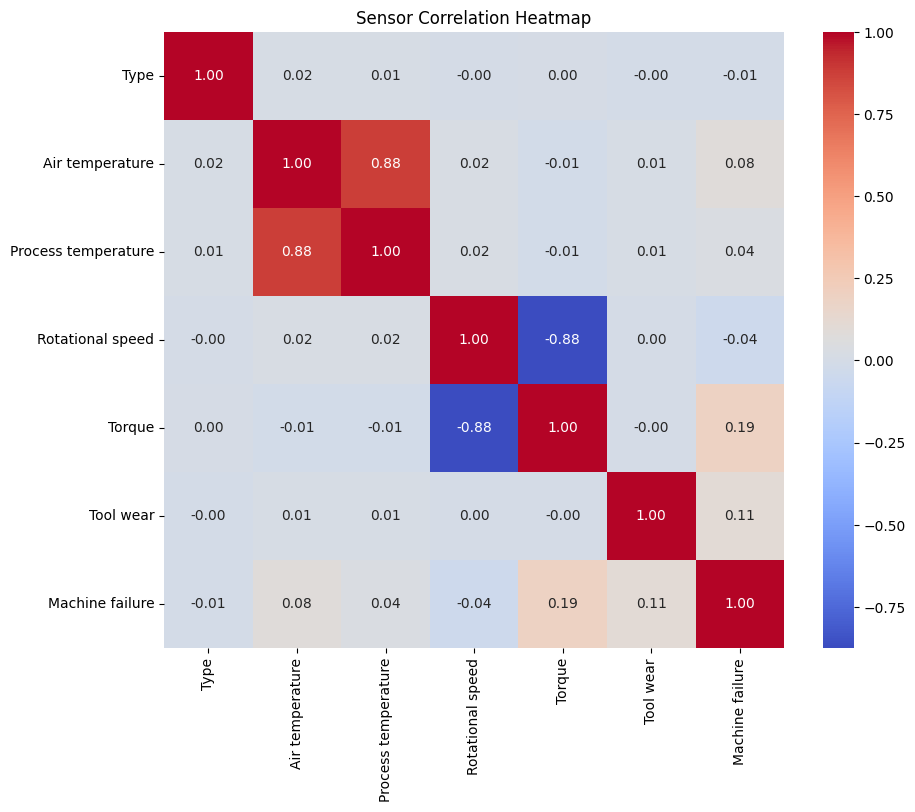

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot target variable distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Machine failure')
plt.title("Distribution of Machine Failures (0: Healthy, 1: Failure)")
plt.show()

# Plot correlation heatmap to see which sensors correlate with failure
plt.figure(figsize=(10, 8))
correlation_matrix = df[features + ['Machine failure']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Sensor Correlation Heatmap")
plt.show()

Model Training and Evaluation

Training Anomaly Detection Model...
Training Complete!


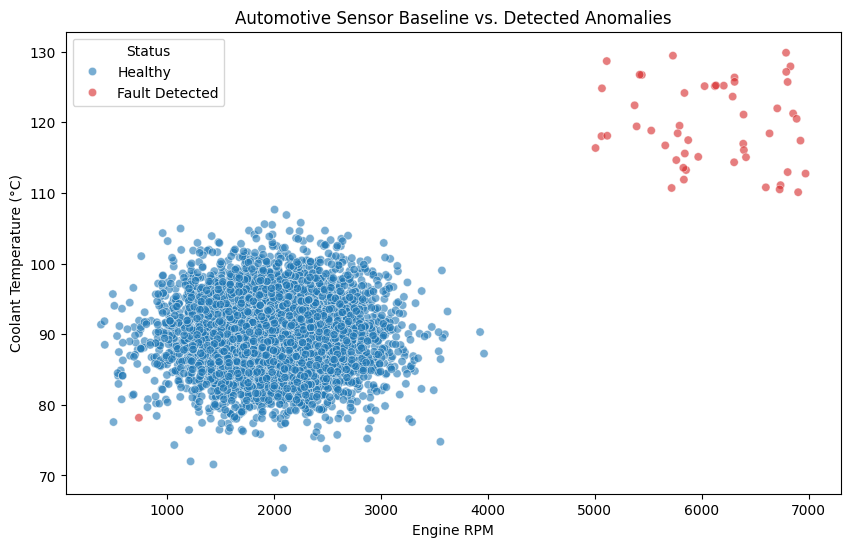


Model and Scaler ready for FastAPI Deployment!


In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# 1. The Dataset
# This generates a highly realistic OBD-II dataset so you can run this immediately.
# Once you download a Kaggle CSV, replace this block with: df = pd.read_csv('your_file.csv')

# --- Generating Simulation Data ---
np.random.seed(42)
n_samples = 5000

# Healthy Driving Baseline (Normal RPM, Temp, Load, Speed)
rpm = np.random.normal(2000, 500, n_samples)
temp = np.random.normal(90, 5, n_samples) # 90 degrees C is normal operating temp
load = np.random.normal(40, 10, n_samples)
speed = np.random.normal(60, 20, n_samples)

df = pd.DataFrame({
    'Engine_RPM': rpm,
    'Coolant_Temp': temp,
    'Engine_Load': load,
    'Vehicle_Speed': speed
})

# Injecting 50 realistic anomalies (e.g., Engine Overheating / High RPM with zero speed)
anomalies = pd.DataFrame({
    'Engine_RPM': np.random.uniform(5000, 7000, 50),
    'Coolant_Temp': np.random.uniform(110, 130, 50), # Overheating
    'Engine_Load': np.random.uniform(80, 100, 50),
    'Vehicle_Speed': np.random.uniform(0, 10, 50) # Revving hard while stopped
})
df = pd.concat([df, anomalies], ignore_index=True)
# ----------------------------------

# 2. Preprocessing
features = ['Engine_RPM', 'Coolant_Temp', 'Engine_Load', 'Vehicle_Speed']
X = df[features]

# We MUST scale the data so RPMs (thousands) don't overpower Temp (tens)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Train the Isolation Forest (The Anomaly Detector)
print("Training Anomaly Detection Model...")
# contamination=0.01 means we expect roughly 1% of the data to be actual faults
iso_forest = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)
iso_forest.fit(X_scaled)
print("Training Complete!")

# 4. Predict and Evaluate
# Isolation Forest returns 1 for INLIERS (Healthy) and -1 for OUTLIERS (Anomalies)
df['Anomaly_Score'] = iso_forest.predict(X_scaled)
df['Status'] = df['Anomaly_Score'].map({1: 'Healthy', -1: 'Fault Detected'})

# 5. Visualize the Results
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Engine_RPM', y='Coolant_Temp', hue='Status',
                palette={'Healthy': '#1f77b4', 'Fault Detected': '#d62728'},
                data=df, alpha=0.6)
plt.title("Automotive Sensor Baseline vs. Detected Anomalies")
plt.xlabel("Engine RPM")
plt.ylabel("Coolant Temperature (°C)")
plt.show()

# 6. Save for Deployment
joblib.dump(iso_forest, 'obd_anomaly_model.pkl')
joblib.dump(scaler, 'obd_scaler.pkl')
print("\nModel and Scaler ready for FastAPI Deployment!")